In [1]:
from statsmodels.genmod.families.links import *
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cskpd_new_update import *

In [2]:
g = Logit()
C_true = np.load("Examples/circles.npy")
np.random.seed(539)
## image shape
img_shape_m,img_shape_n,img_shape_d = 128,128,1
## sample size 
N = 1000
## noise level
sigma = 3
epsilon = np.random.normal(0,1,N) * sigma
X = np.random.normal(0,1,[N, img_shape_m, img_shape_n, img_shape_d]).squeeze()
if isinstance(g, Identity):
    Y = g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon)
elif isinstance(g, Logit):
    Y = np.random.binomial(1,g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon))
else:
    raise NotImplementedError

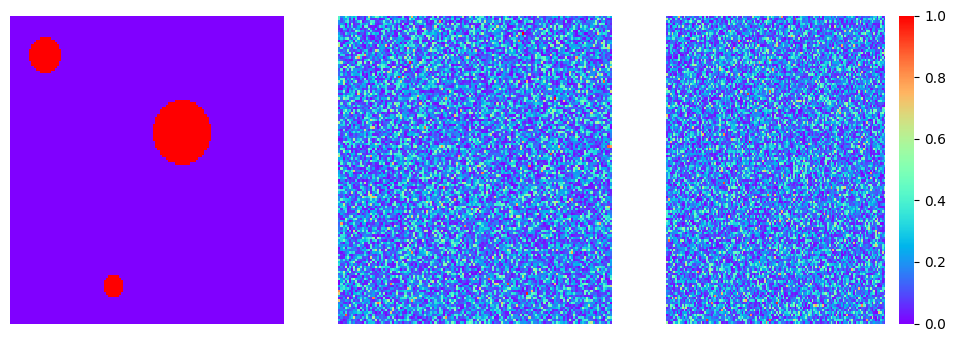

In [3]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(X[np.argmax(Y)]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(X[np.argmin(Y)]),cmap = "rainbow",cbar = True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [4]:
p_list = [[16,16],[32,32]]
lam = [2**i for i in range(-2,1)]
test_model = CSKPD(p_list[1],lama=lam[0],lamb=lam[0],R=1,g=g,n_cores = 1,max_iter = 3,print_iter = 5)
test_model.fit(X,Y,tol=1E-3)
C_mbic = test_model.score['C']

In [5]:
params = {
    'p': p_list,
    'lama': lam,
    'lamb': lam,
    'g': g,
    # 'R': 3,
    'max_iter': 10
}
best_fit_model, all_models = best_fit(X, Y, parameters_dict=params)

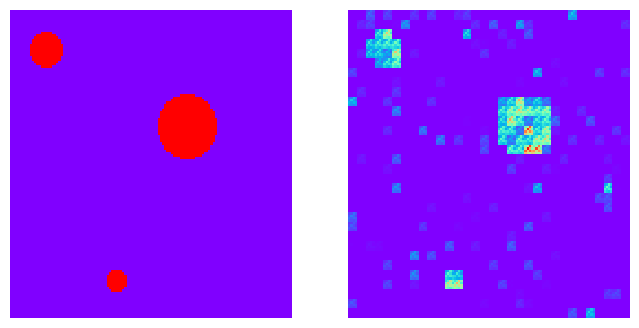

In [6]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (8,4))
ax = plt.subplot(1,2,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,2,2)
sns.heatmap(fun_normalization(best_fit_model.score['C']),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

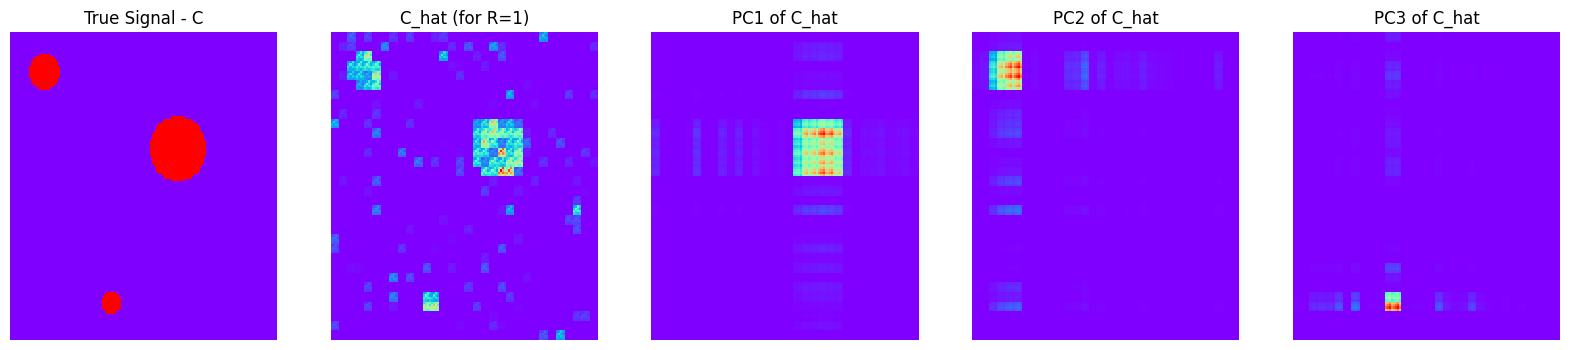

In [7]:
u, s, v = np.linalg.svd(best_fit_model.score['C'])
plt.figure(figsize= (20,4))
ax = plt.subplot(1,5,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("True Signal - C")
ax = plt.subplot(1,5,2)
sns.heatmap(fun_normalization(best_fit_model.score['C']),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"C_hat (for R=1)")
ax = plt.subplot(1,5,3)
r = 1
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
ax = plt.subplot(1,5,4)
r = 2
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
ax = plt.subplot(1,5,5)
r = 3
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
plt.show()

In [8]:
y_meta = []
y_meta_scores = []
top_models = [all_models[i] for i in np.array([m.score['MBIC'] for m in all_models]).argsort()[:5]]
for m in top_models:
    y_meta.append(m.predict(X))
    y_meta_scores.append(m.score['MBIC'])
y_meta = np.array(y_meta).T

In [9]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
gbtd = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.4,
    min_samples_leaf=8,
)
gbtd.fit(y_meta, Y)

GradientBoostingRegressor(learning_rate=0.01, max_depth=5, min_samples_leaf=8,
                          n_estimators=300, subsample=0.4)

In [10]:
N_new = 1000
np.random.seed(536)
epsilon = np.random.normal(0,1,N_new) * sigma
X_new = np.random.normal(0,1,[N_new, img_shape_m, img_shape_n, img_shape_d]).squeeze()
Y_new = np.random.binomial(1,g.inverse(np.tensordot(X_new, C_true, axes=([1,2], [0,1])) + epsilon))

In [11]:
y_meta_new = []
aucs = []
for m in top_models:
    pred = m.predict(X_new)
    aucs.append(auc(pred,Y_new))
    y_meta_new.append(pred)
y_meta_new = np.array(y_meta_new).T
print(aucs)
print(np.mean(aucs))
print(auc(gbtd.predict(y_meta_new),Y_new))

[0.7944748682967446, 0.691362226003403, 0.7178458424503281, 0.7278462024632887, 0.7836058883078116]
0.7430270055043152
0.7808964943439096


In [12]:
print(auc(np.mean(y_meta_new, axis=1),Y_new))

0.7366285769156904
